# Extração dos Arquivos tratados

In [1]:
import pandas as pd
df = pd.read_csv('/content/challenge_telecomX.csv')

# Remoção de colunas irrelevantes

Eliminação das colunas que não trazem valor para a análise ou para os modelos preditivos, como identificadores únicos (por exemplo, o ID do cliente e dados redundantes). Essas colunas não ajudam na previsão da evasão e podem até prejudicar o desempenho dos modelos.

In [2]:
df = df.drop('Unnamed: 0', axis = 1)
df = df.drop('contas_diarias', axis = 1)

In [3]:
colunas_binarias = [
'Churn','tem +65','possui_parceiro','possui_dependentes',
'servico_telefone','multiplas_linhas','seguranca_online',
'backup_online','protecao_dispositivo','suporte_tecnico',
'streaming_tv','streaming_filmes','fatura_digital'
]

df[colunas_binarias] = df[colunas_binarias].astype('category')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Churn                 7032 non-null   category
 1   genero                7032 non-null   object  
 2   tem +65               7032 non-null   category
 3   possui_parceiro       7032 non-null   category
 4   possui_dependentes    7032 non-null   category
 5   tempo_cliente_meses   7032 non-null   int64   
 6   servico_telefone      7032 non-null   category
 7   multiplas_linhas      7032 non-null   category
 8   servico_internet      7032 non-null   object  
 9   seguranca_online      7032 non-null   category
 10  backup_online         7032 non-null   category
 11  protecao_dispositivo  7032 non-null   category
 12  suporte_tecnico       7032 non-null   category
 13  streaming_tv          7032 non-null   category
 14  streaming_filmes      7032 non-null   category
 15  tipo

# Encoding

Transformação das variáveis categóricas em formato numérico para torná-las compatíveis com algoritmos de machine learning. Nesta etapa, utilizamos o metodo one-hot encoding.

In [5]:
colunas_categoricas = ['genero', 'servico_internet', 'tipo_contrato', 'metodo_pagamento']

df_encoded = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)

df_encoded = df_encoded.astype(int)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [6]:
df_encoded

,Churn,tem +65,possui_parceiro,possui_dependentes,tempo_cliente_meses,servico_telefone,multiplas_linhas,seguranca_online,backup_online,protecao_dispositivo,...,gasto_mensal,gasto_total,genero_Masculino,servico_internet_Fibra Opica,servico_internet_Sem servico de internet,tipo_contrato_Bienal,tipo_contrato_Mensal,metodo_pagamento_Cheque eletrônico,metodo_pagamento_Cheque fisico,metodo_pagamento_Transferência bancária
0,0,0,1,1,9,1,0,0,1,0,...,65,593,0,0,0,0,0,0,1,0
1,0,0,0,0,9,1,1,0,0,0,...,59,542,1,0,0,0,1,0,1,0
2,1,0,0,0,4,1,0,0,0,1,...,73,280,1,1,0,0,1,1,0,0
3,1,1,1,0,13,1,0,0,1,1,...,98,1237,1,1,0,0,1,1,0,0
4,1,1,1,0,3,1,0,0,0,0,...,83,267,0,1,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,0,0,0,13,1,0,1,0,0,...,55,742,0,0,0,0,0,0,1,0
7028,1,0,1,0,22,1,1,0,0,0,...,85,1873,1,1,0,0,1,1,0,0
7029,0,0,0,0,2,1,0,0,1,0,...,50,92,1,0,0,0,1,0,1,0
7030,0,0,1,1,67,1,0,1,0,1,...,67,4627,1,0,0,1,0,0,1,0


# Verificação da Proporção de Evasão
Calculamos a proporção de clientes que evadiram em relação aos que permaneceram ativos. Ao termino, avalie se há desequilíbrio entre as classes, o que pode impactar modelos preditivos e a análise de resultados.

In [7]:
# Contagem das classes
contagem = df['Churn'].value_counts()

# Proporção das classes
proporcao = (df['Churn'].value_counts(normalize=True) * 100).astype(int)

print("Contagem de clientes:")
print(contagem)

print("\nProporção:")
print(proporcao)

Contagem de clientes:
Churn
0    5163
1    1869
Name: count, dtype: int64

Proporção:
Churn
0    73
1    26
Name: proportion, dtype: int64


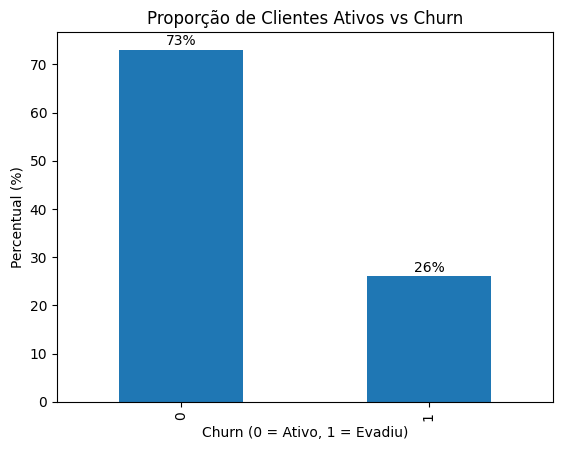

In [25]:
import matplotlib.pyplot as plt

proporcao = (df['Churn'].value_counts(normalize=True) * 100).astype(int)

ax = proporcao.plot(kind='bar')

plt.title('Proporção de Clientes Ativos vs Churn')
plt.xlabel('Churn (0 = Ativo, 1 = Evadiu)')
plt.ylabel('Percentual (%)')

for i, v in enumerate(proporcao):
    ax.text(i, v + 1, f"{v}%", ha='center')

plt.show()

# Análise de Correlação
Visualização e análise da matriz de correlação para identificar relações entre variáveis numéricas.

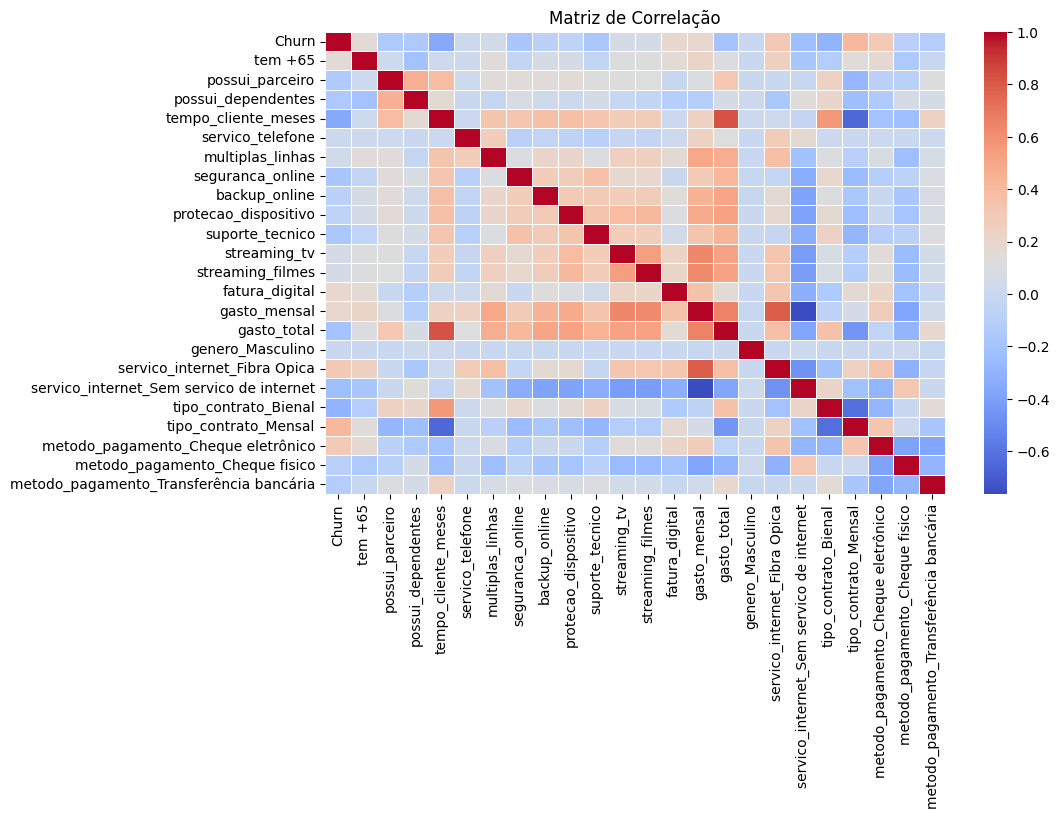

In [27]:
import seaborn as sns

correlacao = df_encoded.corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de Correlação")

plt.show()

In [10]:
correlacao_churn = df_encoded.corr()['Churn'].sort_values(ascending=False)

print(correlacao_churn)

Churn                                       1.000000
tipo_contrato_Mensal                        0.404565
servico_internet_Fibra Opica                0.307463
metodo_pagamento_Cheque eletrônico          0.301455
gasto_mensal                                0.192922
fatura_digital                              0.191454
tem +65                                     0.150541
streaming_tv                                0.063254
streaming_filmes                            0.060860
multiplas_linhas                            0.040033
servico_telefone                            0.011691
genero_Masculino                           -0.008545
protecao_dispositivo                       -0.066193
backup_online                              -0.082307
metodo_pagamento_Cheque fisico             -0.090773
metodo_pagamento_Transferência bancária    -0.118136
possui_parceiro                            -0.149982
possui_dependentes                         -0.163128
suporte_tecnico                            -0.

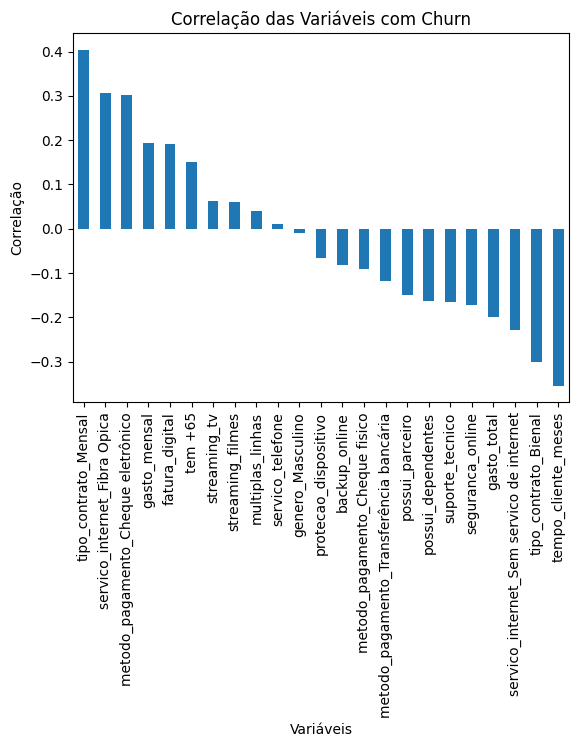

In [29]:
correlacao_churn.drop('Churn').plot(kind='bar')

plt.title("Correlação das Variáveis com Churn")
plt.ylabel("Correlação")
plt.xlabel("Variáveis")

plt.show()

# Análises Direcionadas

Nesta etapa, investigamos como variáveis específicas se relacionam com a evasão, como:

- Tempo de contrato × Evasão

- Total gasto × Evasão

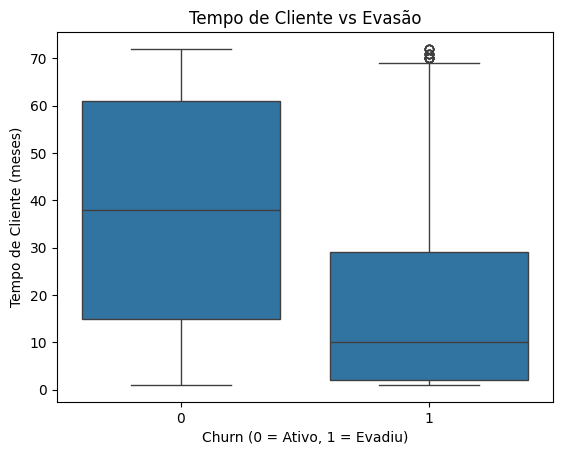

In [32]:
plt.figure()

sns.boxplot(x='Churn', y='tempo_cliente_meses', data=df_encoded)

plt.title('Tempo de Cliente vs Evasão')
plt.xlabel('Churn (0 = Ativo, 1 = Evadiu)')
plt.ylabel('Tempo de Cliente (meses)')

plt.show()

Tempo de cliente × Evasão (Boxplot)

Esse gráfico permite comparar há quanto tempo os clientes permanecem na empresa antes de cancelar.

clientes que cancelam possuem menor tempo de contrato

clientes antigos tendem a permanecer mais.

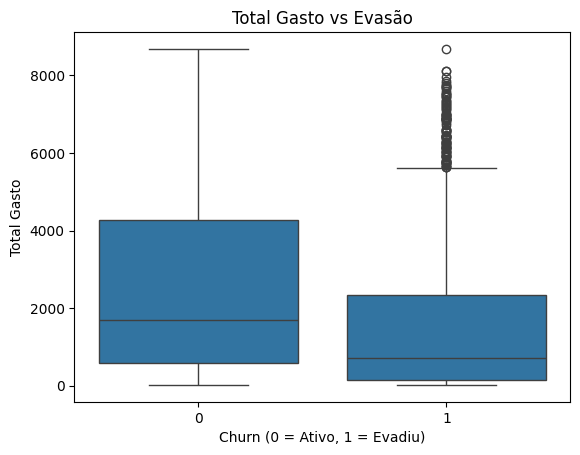

In [34]:
plt.figure()

sns.boxplot(x='Churn', y='gasto_total', data=df_encoded)

plt.title('Total Gasto vs Evasão')
plt.xlabel('Churn (0 = Ativo, 1 = Evadiu)')
plt.ylabel('Total Gasto')

plt.show()

Já esse outro mostra se clientes que cancelam gastam mais ou menos ao longo do tempo.

clientes que cancelam possuem menor gasto total, pois permanecem menos tempo na empresa.

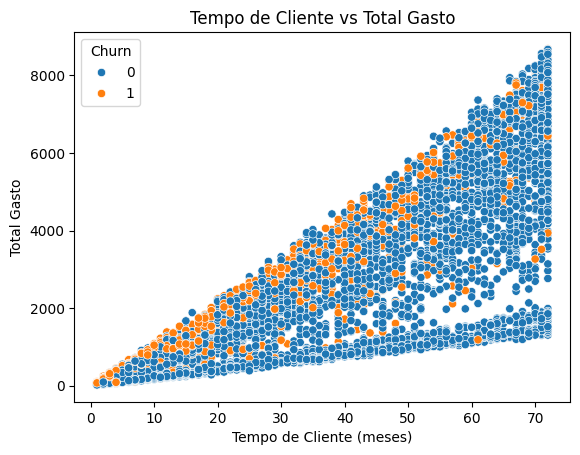

In [36]:
plt.figure()

sns.scatterplot(
    x='tempo_cliente_meses',
    y='gasto_total',
    hue='Churn',
    data=df_encoded
)

plt.title('Tempo de Cliente vs Total Gasto')
plt.xlabel('Tempo de Cliente (meses)')
plt.ylabel('Total Gasto')

plt.show()

Por último, verificamos como tempo de permanência influencia o valor total gasto e como isso se relaciona com churn.

- clientes com baixo tempo de contrato podem concentrar mais churn

- clientes com maior tempo tendem a gastar mais

# Separação dos Dados

Dividimos o conjunto de dados em treino e teste para avaliar o desempenho do modelo. A proporção utilizada foi de Uma divisão comum é 70% para treino e 30%.

In [15]:
from sklearn.model_selection import train_test_split

# Separar variáveis preditoras e variável alvo
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (5625, 23)
Teste: (1407, 23)


## Padronização das Variáveis

In [17]:
from sklearn.preprocessing import StandardScaler

# Criar o scaler
scaler = StandardScaler()

# Selecionar variáveis numéricas
colunas_numericas = ['tempo_cliente_meses', 'gasto_mensal', 'gasto_total']

# Ajustar apenas no conjunto de treino
X_train[colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])

# Aplicar a transformação no conjunto de teste
X_test[colunas_numericas] = scaler.transform(X_test[colunas_numericas])

In [18]:
X_train[colunas_numericas].describe()

,tempo_cliente_meses,gasto_mensal,gasto_total
count,5.625000e+03,5.625000e+03,5.625000e+03
mean,5.115908e-17,1.275819e-16,-6.173827e-17
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.277907e+00,-1.541848e+00,-9.972854e-01
25%,-9.529769e-01,-9.764267e-01,-8.299413e-01
50%,-1.406515e-01,1.876754e-01,-3.915965e-01
75%,9.559880e-01,8.196166e-01,6.656140e-01
max,1.605848e+00,1.784158e+00,2.809024e+00


# Criação de Modelos
## Regressão Lógica

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# criar modelo
modelo_log = LogisticRegression(max_iter=1000)

# treinar modelo
modelo_log.fit(X_train, y_train)

# previsões
y_pred_log = modelo_log.predict(X_test)

# avaliação
print("Acurácia:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Acurácia: 0.798862828713575
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



## Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier

# criar modelo
modelo_rf = RandomForestClassifier(random_state=42)

# treinar modelo
modelo_rf.fit(X_train, y_train)

# previsões
y_pred_rf = modelo_rf.predict(X_test)

# avaliação
print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Acurácia: 0.7882018479033405
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.78      1407



#Avaliação dos modelos
## Regressão Logística

**Acurácia:** 0.80

Classe 0 (Ativo)
- Precision: 0.84
- Recall: 0.90
- F1-score: 0.87

Classe 1 (Churn)
- Precision: 0.65
- Recall: 0.53
- F1-score: 0.58

**Interpretação**

- O modelo identifica 90% dos clientes ativos corretamente.

- Para churn, o modelo identifica 53% dos clientes que realmente cancelam.

- A precisão para churn (0.65) indica que boa parte das previsões de cancelamento são corretas.

## Random Forest

**Acurácia: 0.79**

Classe 0 (Ativo)
- Precision: 0.82
- Recall: 0.91
- F1-score: 0.86

Classe 1 (Churn)
- Precision: 0.64
- Recall: 0.46
- F1-score: 0.54

**Interpretação**

- O modelo identifica 91% dos clientes ativos.

- Porém identifica apenas 46% dos clientes que cancelam.

- Isso significa que o modelo está menos eficiente para detectar churn.




## Avaliação do desequilíbrio

Existe desequilíbrio moderado entre as classes.

- Classe majoritária: Clientes ativos (73%)

- Classe minoritária: Churn (27%)

Esse nível de desbalanceamento não é extremo, mas já pode causar alguns efeitos:

Possíveis impactos nos modelos

Modelos podem:

- favorecer prever "não churn"

- apresentar alta acurácia artificial

## Comparação entre os modelos

### Acurácia

| Modelo              | Acurácia |
| ------------------- | -------- |
| Regressão Logística | **0.80** |
| Random Forest       | 0.79     |


A diferença é pequena, mas a **regressão logística teve melhor desempenho geral.**

### Recall da classe churn

| Modelo              | Recall Churn |
| ------------------- | ------------ |
| Regressão Logística | **0.53**     |
| Random Forest       | 0.46         |

Com esses parâmetros podemos identificar clientes com potencial para cancelamento.

**A regressão logística detecta mais clientes em risco.**

### F1-score dda classe Churn

| Modelo              | F1-score |
| ------------------- | -------- |
| Regressão Logística | **0.58** |
| Random Forest       | 0.54     |

Novamente, a regressão logística apresenta melhor equilíbrio entre precisão e recall

Nos testes realizados a Regressão logística mostrou o melhor desempenho, uma vez que apresentou:

- maior **acurácia**
- maior **recall para churn**
- maior **F1-score para churn**

## Overfitting ou Underfitting

**Overfitting**

Não há evidência clara de overfitting porque:

 - os resultados parecem consistentes

- não há diferença extrema entre métricas


**Possível Underfitting**

Pode haver underfitting moderado, porque:

- o recall de churn ainda é relativamente baixo

- muitos clientes que cancelam não estão sendo identificados

## Análise da Importância das Variáveis
###Regressão Logística (coeficientes)

Os coeficientes indicam o impacto de cada variável na probabilidade de churn.

- coeficiente positivo (aumenta chance de churn)

- coeficiente negativo (reduz chance de churn)

In [21]:
coeficientes = pd.DataFrame({
    'Variavel': X_train.columns,
    'Coeficiente': modelo_log.coef_[0]
})

coeficientes.sort_values(by='Coeficiente', ascending=False)

,Variavel,Coeficiente
16,servico_internet_Fibra Opica,0.778698
19,tipo_contrato_Mensal,0.712894
14,gasto_total,0.615146
20,metodo_pagamento_Cheque eletrônico,0.442650
12,fatura_digital,0.369301
10,streaming_tv,0.285854
0,tem +65,0.254032
5,multiplas_linhas,0.214697
11,streaming_filmes,0.145503
22,metodo_pagamento_Transferência bancária,0.084259


### Random Forest

O Random Forest mede a importância com base na redução da impureza nas árvores.

In [22]:
importancia = pd.DataFrame({
    'Variavel': X_train.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancia.sort_values(by='Importancia', ascending=False)

,Variavel,Importancia
14,gasto_total,0.184357
3,tempo_cliente_meses,0.171544
13,gasto_mensal,0.137574
19,tipo_contrato_Mensal,0.073005
16,servico_internet_Fibra Opica,0.043356
20,metodo_pagamento_Cheque eletrônico,0.041764
15,genero_Masculino,0.031537
12,fatura_digital,0.028686
1,possui_parceiro,0.025287
0,tem +65,0.023475


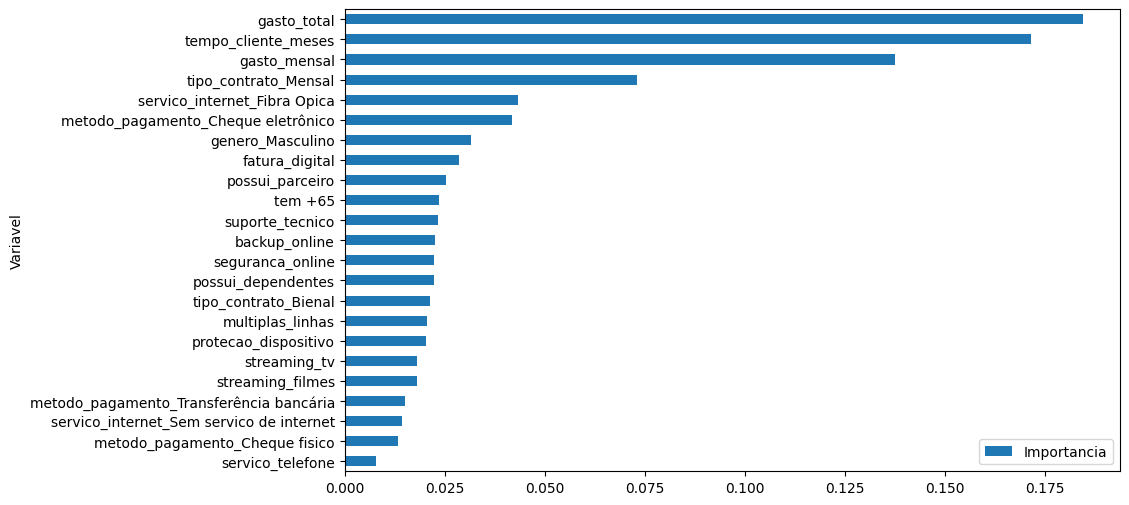

In [37]:
importancia.sort_values(by='Importancia').plot(
    x='Variavel',
    y='Importancia',
    kind='barh',
    figsize=(10,6)
)



### Conclusão
A análise mostrou que:

- A Regressão Logística apresentou melhor desempenho geral.

- O modelo consegue prever churn com 80% de acurácia.

- Entretanto, ainda há espaço para melhoria na detecção de clientes que cancelam.

As variáveis mais relevantes indicam que tempo de permanência, tipo de contrato e serviços adicionais são fatores importantes para prever evasão.

# Relatório de Análise e Modelagem de Evasão de Clientes

---


##Introdução

---



A evasão de clientes (churn) representa um grande desafio para empresas de telecomunicações, pois impacta diretamente a receita e os custos de aquisição de novos clientes.

O objetivo deste projeto foi desenvolver modelos preditivos capazes de identificar clientes com maior probabilidade de cancelar seus serviços, permitindo que a empresa implemente estratégias de retenção antes que a evasão ocorra.

Para isso, foi realizado um processo completo de ciência de dados, incluindo:

- limpeza e preparação dos dados

- análise exploratória

- engenharia de atributos

- treinamento e avaliação de modelos preditivos

## Preparação e Exploração dos Dados

---



O dataset contém 7032 registros de clientes com variáveis relacionadas a:

- perfil do cliente

- serviços contratados

- tipo de contrato

- forma de pagamento

- histórico de gastos

- tempo de relacionamento com a empresa

### Principais etapas realizadas

- Remoção de colunas irrelevantes (ex.: identificadores)

- Transformação de variáveis categóricas com One-Hot Encoding

- Análise de balanceamento da variável alvo (Churn)

- Padronização das variáveis numéricas

- Separação dos dados em treino (80%) e teste (20%)

- Distribuição da variável alvo:

| Classe                  | Proporção |
| ----------------------- | --------- |
| Clientes ativos         | ~73%      |
| Clientes que cancelaram | ~27%      |



## Modelos Desenvolvidos

---

Foram utilizados dois modelos de Machine Learning:

### Regressão Logística

Modelo linear amplamente utilizado para problemas de classificação binária.

Características:

- requer normalização dos dados

- alta interpretabilidade

- bom modelo baseline

### Random Forest

Modelo baseado em conjunto de árvores de decisão.

Características:

- captura relações não lineares

- robusto a ruído

- não depende da escala das variáveis

## Avaliação dos Modelos

---

**Regressão Logística**
**Acurácia: 0.80**

| Métrica   | Classe Ativo | Classe Churn |
| --------- | ------------ | ------------ |
| Precision | 0.84         | 0.65         |
| Recall    | 0.90         | 0.53         |
| F1-score  | 0.87         | 0.58         |


**Random Forest**
**Acurácia: 0.79**

| Métrica   | Classe Ativo | Classe Churn |
| --------- | ------------ | ------------ |
| Precision | 0.82         | 0.64         |
| Recall    | 0.91         | 0.46         |
| F1-score  | 0.86         | 0.54         |



## Comparação dos Modelos

---

| Modelo              | Acurácia | Recall Churn | F1-score |
| ------------------- | -------- | ------------ | -------- |
| Regressão Logística | **0.80** | **0.53**     | **0.58** |
| Random Forest       | 0.79     | 0.46         | 0.54     |


Como podemos notar, a Regressão Logística apresentou melhor desempenho, especialmente na identificação de clientes que cancelam (recall da classe churn).

Embora a diferença seja pequena, esse modelo demonstrou melhor capacidade de detectar clientes em risco de evasão, o que é essencial para ações de retenção.

## Principais Fatores que Influenciam a Evasão

---

A análise dos coeficientes da Regressão Logística e da importância das variáveis no Random Forest revelou alguns fatores críticos.

### Fatores que aumentam a evasão
**Tipo de contrato mensal**

Clientes com contratos mensais apresentam maior probabilidade de cancelamento, possivelmente devido à ausência de compromisso de longo prazo.

**Baixo tempo de relacionamento**

Clientes com poucos meses de contrato apresentam maior tendência a cancelar.

Isso sugere que os primeiros meses são críticos para retenção.

**Ausência de serviços adicionais**

Clientes que não possuem serviços como:

- suporte técnico

- segurança online

- backup online

tendem a cancelar com maior frequência.

**Planos com maior custo mensal**

Clientes com maior gasto mensal podem apresentar maior probabilidade de evasão, possivelmente por insatisfação com custo-benefício.

## Estratégias de Retenção Recomendadas

---

Com base nos resultados obtidos, algumas estratégias podem ser implementadas.

### Programa de retenção para novos clientes

Clientes com pouco tempo de contrato devem receber:

- acompanhamento inicial

- suporte dedicado

- ofertas personalizadas

Isso pode reduzir o churn nos primeiros meses.

### Incentivo a contratos de longo prazo

Oferecer benefícios para migração para contratos anuais ou bienais, como:

- descontos

- serviços adicionais gratuitos

- upgrades de plano

### Pacotes de serviços agregados

Clientes com mais serviços tendem a permanecer mais tempo.

Estratégia:

- oferecer bundles com:

  - segurança online

  - suporte técnico

  - streaming

### Monitoramento de clientes com alto gasto mensal

Clientes com contas elevadas podem estar mais sensíveis a cancelamento.

Possíveis ações:

- revisão de plano

- descontos personalizados

- melhoria na experiência do cliente

## Conclusão

---

A análise realizada demonstrou que é possível identificar padrões relevantes associados à evasão de clientes utilizando técnicas de ciência de dados e modelos de Machine Learning.

Entre os modelos testados, a Regressão Logística apresentou o melhor desempenho geral, alcançando 80% de acurácia e um recall de 53% para clientes que cancelam, o que indica uma capacidade razoável de detectar clientes com risco de evasão. Embora ainda exista espaço para melhoria na identificação de churn, o modelo já se mostra útil como ferramenta de apoio à tomada de decisão e pode ser incorporado a processos de monitoramento preventivo.

Os resultados também evidenciaram fatores importantes que influenciam o comportamento de cancelamento. Clientes com contratos mensais, baixo tempo de relacionamento, ausência de serviços adicionais e maior custo mensal apresentam maior probabilidade de evasão. Esses padrões sugerem que o churn não ocorre de forma aleatória, mas sim associado a características específicas da jornada do cliente.

Um ponto particularmente relevante é que os primeiros meses de relacionamento representam um período crítico para retenção, indicando a necessidade de estratégias de acompanhamento mais próximas nesse estágio. Além disso, a análise sugere que clientes que utilizam mais serviços da empresa tendem a permanecer por mais tempo, reforçando o valor de estratégias de venda de pacotes e serviços agregados.

Do ponto de vista estratégico, a utilização de modelos preditivos como o desenvolvido neste projeto permite que a empresa transite de uma abordagem reativa para uma abordagem preventiva de retenção, direcionando esforços e recursos para clientes com maior probabilidade de cancelamento.

Como próximos passos, recomenda-se:

- integrar o modelo a sistemas operacionais ou CRM para monitoramento contínuo de churn;

- testar estratégias de retenção direcionadas aos clientes identificados como de alto risco;

- aprimorar o modelo com novas variáveis comportamentais e dados de interação com o cliente;

- explorar técnicas adicionais de modelagem, como Gradient Boosting ou XGBoost, que podem aumentar a capacidade preditiva.